# Bonus Components

1. Introduction & Setup
2. Load Final Clusters
3. Financial Impact Modeling
   - CLV proxy
   - ROI analysis
4. Fuzzy Clustering
   - c-means
   - membership analysis
5. Key Visualizations
6. Summary of Insights

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#!pip install scikit-fuzzy
import skfuzzy as fuzz

## Load Final Clusters

In [2]:
df_clustering = pd.read_csv("../cluster_data/final_clusters.csv").set_index("Loyalty#")
df_categorical = pd.read_csv("../cluster_data/categorical_features.csv").set_index("Loyalty#")
df_VE = pd.read_csv("../cluster_data/df_VE.csv").set_index("Loyalty#")
df_PP = pd.read_csv("../cluster_data/df_PP.csv").set_index("Loyalty#")
dataset_before_fs = pd.read_csv("../cluster_data/dataset_before_feature_selection.csv").set_index("Loyalty#")

In [3]:
df_clustering

,Income,Months_Enrolled,Total_Flights,Total_Flights_With_Companions,Total_DistanceKM,Total_Points_Redeemed,Flights_Variance,Recency,Winter_Flights_Ratio,Spring_Flights_Ratio,Summer_Flights_Ratio,Autumn_Flights_Ratio,merged_labels,pca_1,pca_2,pca_3
Loyalty#,,,,,,,,,,,,,,,,
480934,0.701593,0.680556,0.352490,0.378571,0.484857,0.248267,0.500602,0.00,0.092391,0.250000,0.451087,0.206522,0,-0.290315,0.326306,0.119701
549612,0.000000,0.673611,0.478927,0.164286,0.387002,0.159723,0.596411,0.00,0.208000,0.332000,0.232000,0.228000,1,-0.239636,-0.376821,0.035785
429460,0.000000,0.736111,0.222222,0.264286,0.227940,0.100637,0.334411,0.11,0.250000,0.318966,0.172414,0.258621,1,0.049555,-0.377532,-0.025875
608370,0.000000,0.930556,0.365900,0.392857,0.369129,0.299941,0.442464,0.00,0.246073,0.345550,0.188482,0.219895,1,-0.273655,-0.376280,0.141912
530508,0.978506,0.791667,0.319923,0.421429,0.353078,0.000000,0.578611,0.00,0.221557,0.167665,0.425150,0.185629,0,-0.249638,0.603486,0.079028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344232,0.846661,0.979167,0.348659,0.314286,0.490223,0.260100,0.370730,0.01,0.280220,0.329670,0.302198,0.087912,0,-0.260177,0.470369,0.213810
546773,0.000000,0.715278,0.371648,0.242857,0.355285,0.085737,0.424732,0.01,0.252577,0.175258,0.355670,0.216495,1,-0.137251,-0.375729,-0.014807
302628,0.407477,0.923611,0.423372,0.264286,0.419202,0.108266,0.506734,0.02,0.199095,0.375566,0.276018,0.149321,1,-0.262795,0.031904,0.184550


In [4]:
df_categorical

,Country,Province or State,City,Gender,Education,Location Code,Marital Status,LoyaltyStatus,EnrollmentType,Income_Bins,Preferred_Season,CLV_Bins
Loyalty#,,,,,,,,,,,,
480934,Canada,Ontario,Toronto,female,Bachelor,Urban,Married,Star,Standard,High,Summer_Flights,Low
549612,Canada,Alberta,Edmonton,male,College,Rural,Divorced,Star,Standard,Low,Spring_Flights,Low
429460,Canada,British Columbia,Vancouver,male,College,Urban,Single,Star,Standard,Low,Spring_Flights,Low
608370,Canada,Ontario,Toronto,male,College,Suburban,Single,Star,Standard,Low,Spring_Flights,Low
530508,Canada,Quebec,Hull,male,Bachelor,Suburban,Married,Star,2021 Promotion,High,Summer_Flights,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
344232,Canada,Quebec,Tremblant,male,Bachelor,Rural,Married,Star,Standard,High,Spring_Flights,High
546773,Canada,British Columbia,Vancouver,male,College,Suburban,Married,Star,Standard,Low,Summer_Flights,High
302628,Canada,Quebec,Tremblant,male,Bachelor,Rural,Single,Star,Standard,Medium,Spring_Flights,High


## 1. Financial Impact Modeling

In [5]:
df_bonus = df_clustering.merge(
    df_categorical,
    on="Loyalty#",
    how="left"
)

df_bonus['CLV'] = dataset_before_fs['Customer Lifetime Value']

In [6]:
clv_distribution = pd.crosstab(
        df_bonus["merged_labels"],
        df_bonus["CLV_Bins"],
        normalize="index"
    )

clv_distribution

CLV_Bins,High,Low,Medium
merged_labels,,,
0,0.353860,0.301517,0.344623
1,0.325965,0.348607,0.325429
2,0.286254,0.380665,0.333082
3,0.321081,0.335135,0.343784
4,0.339529,0.332094,0.328377
5,0.340013,0.319973,0.340013


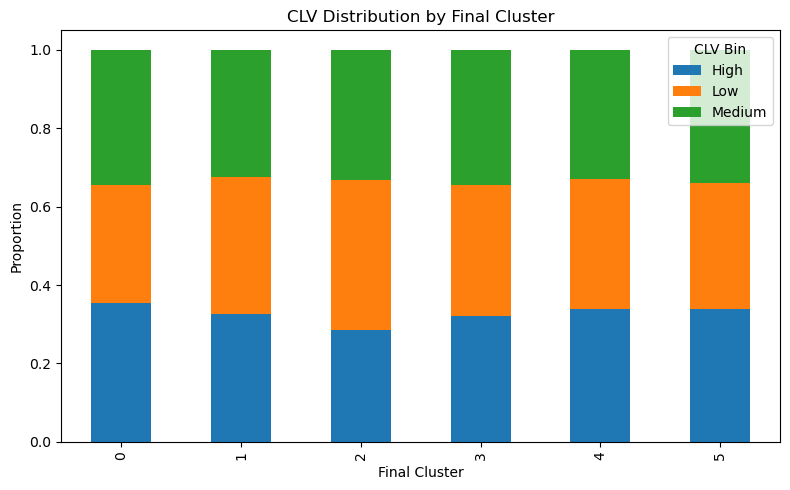

In [7]:
clv_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("CLV Distribution by Final Cluster")
plt.ylabel("Proportion")
plt.xlabel("Final Cluster")
plt.legend(title="CLV Bin")
plt.tight_layout()
plt.show()


In [ ]:
clv_map = {"Low": 1, "Medium": 2, "High": 3}
df_bonus["CLV_score"] = df_bonus["CLV_Bins"].map(clv_map)

cluster_value = (
    df_bonus
    .groupby("merged_labels")
    .agg(
        avg_clv=("CLV", "mean"),        
        avg_clv_score=("CLV_score", "mean"),  
        size=("CLV", "count")
    )
    .sort_values("avg_clv_score", ascending=False)
)
cluster_value

,avg_clv,avg_clv_score,size
merged_labels,,,
0,0.107284,2.052342,4547
5,0.111035,2.020040,1497
4,0.106379,2.007435,807
3,0.100824,1.985946,925
1,0.105153,1.977358,7464
2,0.094380,1.905589,1324


In [9]:
q1 = cluster_value["avg_clv_score"].quantile(0.33)
q2 = cluster_value["avg_clv_score"].quantile(0.66)

def assign_priority(x):
    if x >= q2:
        return "High priority"
    elif x >= q1:
        return "Medium priority"
    else:
        return "Low priority"

cluster_value["priority"] = cluster_value["avg_clv_score"].apply(assign_priority)
cluster_value

,avg_clv,avg_clv_score,size,priority
merged_labels,,,,
0,0.107284,2.052342,4547,High priority
5,0.111035,2.020040,1497,High priority
4,0.106379,2.007435,807,Medium priority
3,0.100824,1.985946,925,Medium priority
1,0.105153,1.977358,7464,Low priority
2,0.094380,1.905589,1324,Low priority


In [10]:
assumptions = {
    "High priority":   {"cost": 8, "lift": 0.05},
    "Medium priority": {"cost": 5, "lift": 0.03},
    "Low priority":    {"cost": 2, "lift": 0.01},
}

In [11]:
roi_table = cluster_value.copy()

roi_table["cost_per_customer"] = roi_table["priority"].map(
    lambda x: assumptions[x]["cost"]
)

roi_table["expected_lift"] = roi_table["priority"].map(
    lambda x: assumptions[x]["lift"]
)

target_rate = {
    "High priority": 0.6,
    "Medium priority": 0.4,
    "Low priority": 0.2
}

roi_table["customers_targeted"] = (
    roi_table["size"] *
    roi_table["priority"].map(target_rate)
)


roi_table["expected_benefit"] = (
    roi_table["avg_clv"] *
    roi_table["expected_lift"] *
    roi_table["customers_targeted"]
)

roi_table["expected_cost"] = (
    roi_table["cost_per_customer"] *
    roi_table["customers_targeted"]
)

roi_table["ROI"] = (
    (roi_table["expected_benefit"] - roi_table["expected_cost"]) /
    roi_table["expected_cost"]
)

roi_table.sort_values("ROI", ascending=False)

timeline = roi_table[[
    "priority",
    "avg_clv",
    "avg_clv_score",
    "size",
    "ROI"
]].copy()

timeline

,priority,avg_clv,avg_clv_score,size,ROI
merged_labels,,,,,
0,High priority,0.107284,2.052342,4547,-0.999329
5,High priority,0.111035,2.020040,1497,-0.999306
4,Medium priority,0.106379,2.007435,807,-0.999362
3,Medium priority,0.100824,1.985946,925,-0.999395
1,Low priority,0.105153,1.977358,7464,-0.999474
2,Low priority,0.094380,1.905589,1324,-0.999528


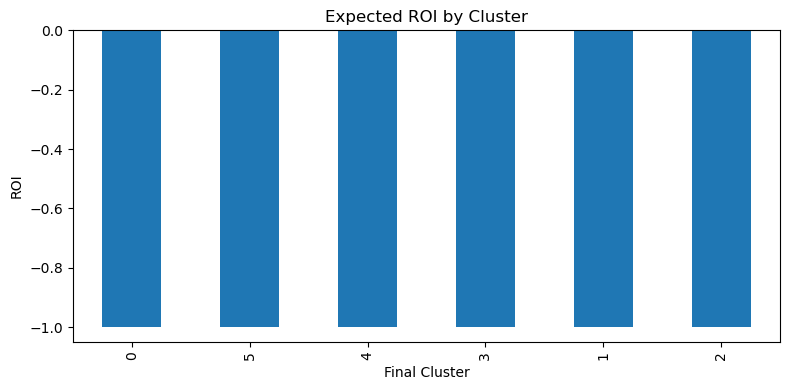

In [13]:
roi_table["ROI"].plot(kind="bar", figsize=(8, 4))
plt.title("Expected ROI by Cluster")
plt.ylabel("ROI")
plt.xlabel("Final Cluster")
plt.tight_layout()
plt.show()


## 2. Fuzzy Clustering Implementation

In [ ]:
#pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 8.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Prepare matrices
X_VE = df_VE.select_dtypes(include=[np.number]).to_numpy()
X_PP = df_PP.select_dtypes(include=[np.number]).to_numpy()

In [22]:
# Fuzzy C-Means parameters
c_VE = 6   # same k used in k-means (VE perspective)
c_PP = 5   # same k used in k-means (PP perspective)


# Run FCM – VE
cntr_VE, U_VE, _, _, jm_VE, _, fpc_VE = fuzz.cluster.cmeans(
    X_VE.T, c=c_VE, m=2.0, error=1e-5, maxiter=1000, init=None, seed=42
)

U_VE = U_VE.T  # (n_samples, c)
labels_fcm_VE = np.argmax(U_VE, axis=1)

u_max_VE = U_VE.max(axis=1)
u_sorted_VE = np.sort(U_VE, axis=1)
margin_VE = u_sorted_VE[:, -1] - u_sorted_VE[:, -2]

# Run FCM – PP
cntr_PP, U_PP, _, _, jm_PP, _, fpc_PP = fuzz.cluster.cmeans(
    X_PP.T, c=c_PP, m=2.0, error=1e-5, maxiter=1000, init=None, seed=42
)

U_PP = U_PP.T
labels_fcm_PP = np.argmax(U_PP, axis=1)

u_max_PP = U_PP.max(axis=1)
u_sorted_PP = np.sort(U_PP, axis=1)
margin_PP = u_sorted_PP[:, -1] - u_sorted_PP[:, -2]


# Quick sanity checks
print("VE FPC:", fpc_VE, "| High confidence share:", (u_max_VE >= 0.7).mean())
print("PP FPC:", fpc_PP, "| High confidence share:", (u_max_PP >= 0.7).mean())


VE FPC: 0.40704158476192054 | High confidence share: 0.20212509055783628
PP FPC: 0.3363281604929523 | High confidence share: 0.09369717459550833
